# F7 flow-conditioned curve fade — the QueryDrivenBacktest implementation

**F7 is DEAD AT GATE** (ledger `V-F7`). Nothing here reopens it. This notebook
re-expresses the registered rule in the production engine, because session 2
established that *making a strategy executable finds defects that panels hide* —
all three of that session's QDB notebooks moved a graded number, always
downward.

**The arm is chosen adversarially.** The registered headline is the MEDIAN
increment across all ten signatures (`L-0082`: never the best). For an
executable check the right choice is the opposite — the single **most
favourable cell in the entire gate**, `5-10` at `h=21`, whose shock book beats
its no-shock book by **+3.75 bp** of median gross, the largest positive
increment anywhere in the table. If even that cell dies in the engine at the
registered cost line, the death is over-determined.

**What making it executable forces into the open**, and what this notebook
measures:

1. **The mark changes.** The gate marks on the banked Citi **quoted par grid**
   (`par_grid_USD_SOFR.parquet`); the engine prices real spot 5Y/10Y swaps off
   the bootstrapped `USD-SOFR-1D-CITIVELOEXCEL` CurveStore. Those are different
   objects and the tie-out has to say by how much.
2. **DV01 is not 1.0.** The gate works in bp of a rate-space spread; the engine
   holds two swaps whose realised DV01 drifts with the level.
3. **Costs land at the unwind.** `UnwindPositionsAction.fee` is the engine's
   only cost hook (design landmine 6), so the whole round trip is charged at
   exit.

Two assertions are mandatory and are the reason this notebook can be trusted at
all: **non-zero marks** and a **closed-position count**. A book that never
traded also has no equity-curve holes and no NaNs — that signature caught the
`DateTriggerRequirements` silent no-op in `sv_h13_qdb` and the `curve_source`
no-op in `sv_h16b_qdb`. A handsome equity curve of a book that never traded is
*more* persuasive, not less.

In [1]:
import os

os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")

import json
import pathlib
import sys
import time

import numpy as np
import pandas as pd

_REPO = (pathlib.Path(__file__).resolve().parents[3] if "__file__" in dir()
         else pathlib.Path.cwd().parents[2])
sys.path.insert(0, str(_REPO))
sys.path.insert(0, str(_REPO / "scripts"))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from BT.data_handler import TimeGrid
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements
from BT.signals.deflated_sharpe import deflated_sharpe
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue
from RVUtils.SFRRVLab.stats import nonoverlapping_sharpe, nw_tstat

from s3_f7_gate import (FLOW_WIN, HORIZONS, SHOCK_Q, Z_ENTRY, Z_WIN, CM2_HALF,
                        episodes, round_trips, shock_flags, structure_series, zscore)

DATA = _REPO / "notebooks" / "data" / "citivelo_rv"
CURVE = "USD-SOFR-1D"
SIG, H = "5-10", 21                 # the most favourable cell in the whole gate
SHORT_T, LONG_T = "5Y", "10Y"
LEG_DV01 = 100_000.0                # $ per bp per leg
TRIALS_TOTAL = 55                   # ledger N at V-F7: 37 + 18 (K=10 registered + 8 superset)

RT_BP = round_trips(SIG)["rt_cm2"]  # 1.8 bp, the registered governing line
print(f"arm {SIG} h={H}bd   registered round trip {RT_BP:.2f} bp "
      f"(CM-2 measured flat {CM2_HALF} bp/leg, sum|w| x 2 x hs)")

C:\Users\chris\clee\ARBS-rv\Query\IRSwaps\IRSwapStructure.py:12: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  from rateslib.scheduling import get_imm, next_imm


arm 5-10 h=21bd   registered round trip 1.80 bp (CM-2 measured flat 0.45 bp/leg, sum|w| x 2 x hs)


## 1. Rebuild the signal panel and assert it reproduces the gate

The episodes must come out **byte-equal** to the committed gate artifact. If
they do not, the engine is being pointed at a different strategy than the one
that was killed, and every number below would be about something else.

In [2]:
par = pd.read_parquet(DATA / "par_grid_USD_SOFR.parquet")
par.index = pd.to_datetime(par.index)
pkg = pd.read_parquet(DATA / "f7_packages.parquet")
pkg["file_date"] = pd.to_datetime(pkg["file_date"])
dg_all = pd.read_parquet(DATA / "f7_extract_diag.parquet")
file_dates = pd.DatetimeIndex(pd.to_datetime(dg_all["file_date"]))

common = par.index.intersection(file_dates)
x = structure_series(par, SIG).reindex(common).dropna()
flow = (pkg[pkg["signature"] == SIG].groupby("file_date").size()
        .reindex(x.index, fill_value=0).astype(float))
z = zscore(x, Z_WIN)
shock = shock_flags(flow, FLOW_WIN, SHOCK_Q)
persistent = ((z.abs() >= Z_ENTRY) & (np.sign(z) == np.sign(z.shift(1)))
              & (z.shift(1).abs() >= Z_ENTRY))

tr_shock = episodes(x, z, persistent & shock, H)
tr_nosh = episodes(x, z, persistent & ~shock, H)
print(f"panel episodes: shock {len(tr_shock)}, no-shock {len(tr_nosh)}")

gate = pd.read_parquet(DATA / "f7_gate.parquet")
g_row = gate[(gate.signature == SIG) & (gate.h == H) & (gate.book == "shock")].iloc[0]
assert int(g_row["n"]) == len(tr_shock), (
    f"episode count drift vs committed gate: {g_row['n']} vs {len(tr_shock)}")
assert abs(float(g_row["gross_med"]) - tr_shock["gross_bp"].median()) < 1e-9, (
    "gross median drift vs committed gate")
print(f"TIE-OUT to committed gate artifact: PASS "
      f"(n={len(tr_shock)}, gross_med={tr_shock['gross_bp'].median():+.4f} bp)")

panel episodes: shock 15, no-shock 20
TIE-OUT to committed gate artifact: PASS (n=15, gross_med=+1.3180 bp)


## 2. Harness sign probe (charter point 11)

Landmine 1: `QueryDrivenBacktest` signed-bpv direction blindness was reported
unfixed on 2026-07-30 and repaired in this program at `L-0012`. It is re-run
**in this session on this code state**, because a green test from a previous
session is not evidence about this one. Buy and sell of the same structure must
mirror exactly.

In [3]:
def sign_probe() -> dict:
    days = [d for d in x.index[-40:]]
    grid = TimeGrid([pd.Timestamp(d) for d in days])
    mdp = IRSwapsMDP(source="CITIVELO_EXCEL")
    out = {}
    for bpv in (+LEG_DV01, -LEG_DV01):
        q = IRSwapQuery(structure=IRSwapStructure.OUTRIGHT, value=IRSwapValue.NPV,
                        tenor=LONG_T, curve=CURVE,
                        structure_kwargs={"bpv": bpv}, tags=("probe",))
        strat = QueryStrategy(name=f"probe_{bpv:+.0f}", triggers=[
            DateTrigger(DateTriggerRequirements(dates=[pd.Timestamp(days[0]).date()]),
                        actions=[AddQueryAction(query=q, meta={"tags": ["probe"]})]),
            DateTrigger(DateTriggerRequirements(dates=[pd.Timestamp(days[-1]).date()]),
                        actions=[UnwindPositionsAction(match_tag="probe", fee=0.0)]),
        ])
        bt = QueryDrivenBacktest(time_grid=grid, strategy=strat, mdp=mdp)
        bt.run()
        eq = pd.Series(bt.mtm_history).sort_index()
        out[bpv] = float(eq.iloc[-1])
    return out


probe = sign_probe()
pay, rec = probe[+LEG_DV01], probe[-LEG_DV01]
d_rate = float(x.iloc[-1] - x.iloc[-40])
print(f"sign probe: pay {pay:+,.0f}  receive {rec:+,.0f}  (10Y leg, last 40 marked days)")
assert abs(pay + rec) < max(1.0, 1e-6 * max(abs(pay), abs(rec))), (
    f"pay and receive do not mirror: {pay:+,.0f} vs {rec:+,.0f} — direction blindness")
print("MIRROR: PASS — the engine is not direction-blind on this code state")

BACKTESTING...:   0%|          | 0/40 [00:00<?, ?step/s]

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\rateslib\data\fixings.py:3426: RuntimeWarning: invalid value encountered in divide
  r = (v[:-1] / v[1:] - 1) * 100 / dcfs_obs[len(populated) :]
BACKTESTING...:   2%|▎         | 1/40 [00:02<01:29,  2.29s/step]

BACKTESTING...:  12%|█▎        | 5/40 [00:02<00:12,  2.75step/s]

BACKTESTING...:  22%|██▎       | 9/40 [00:02<00:05,  5.58step/s]

BACKTESTING...:  32%|███▎      | 13/40 [00:02<00:03,  8.87step/s]

...

BACKTESTING...:  70%|███████   | 28/40 [00:00<00:00, 49.78step/s]

BACKTESTING...:  85%|████████▌ | 34/40 [00:00<00:00, 49.94step/s]

BACKTESTING...: 100%|██████████| 40/40 [00:00<00:00, 50.55step/s]

BACKTESTING...: 100%|██████████| 40/40 [00:00<00:00, 49.80step/s]

sign probe: pay +365,686  receive -365,686  (10Y leg, last 40 marked days)
MIRROR: PASS — the engine is not direction-blind on this code state


## 3. The engine run

`side = -sign(z)` is the fade. Faded from above (`z > 0`, the spread is wide),
the trade profits as `r10 - r5` narrows: **receive 10Y, pay 5Y**. In this
repo's convention `+bpv` pays fixed and `-bpv` receives, so `bpv(10Y) = side x
D` and `bpv(5Y) = -side x D`.

The whole round trip is charged at the unwind: `2 x 2 x 0.45 bp x D`, the
registered CM-2 governing line.

In [4]:
def run_book(trades: pd.DataFrame, name: str) -> tuple:
    triggers, held = [], set()
    for k, r in trades.reset_index(drop=True).iterrows():
        tag = f"ep{k}"
        side = float(r["side"])
        legs = [
            IRSwapQuery(structure=IRSwapStructure.OUTRIGHT, value=IRSwapValue.NPV,
                        tenor=LONG_T, curve=CURVE,
                        structure_kwargs={"bpv": side * LEG_DV01}, tags=(tag,)),
            IRSwapQuery(structure=IRSwapStructure.OUTRIGHT, value=IRSwapValue.NPV,
                        tenor=SHORT_T, curve=CURVE,
                        structure_kwargs={"bpv": -side * LEG_DV01}, tags=(tag,)),
        ]
        # DateTriggerRequirements tests ``state.date() in set(self.dates)``: a
        # pd.Timestamp there never compares equal to a datetime.date and every
        # trigger becomes a SILENT no-op. Hence .date().
        triggers.append(DateTrigger(
            DateTriggerRequirements(dates=[pd.Timestamp(r["entry_date"]).date()]),
            actions=[AddQueryAction(query=q, meta={"tags": [tag]}) for q in legs]))
        triggers.append(DateTrigger(
            DateTriggerRequirements(dates=[pd.Timestamp(r["exit_date"]).date()]),
            actions=[UnwindPositionsAction(match_tag=tag, fee=RT_BP * LEG_DV01)]))
        held.update(pd.date_range(r["entry_date"], r["exit_date"], freq="B"))

    grid_days = sorted(d for d in held if d in set(x.index))
    grid = TimeGrid([pd.Timestamp(d) for d in grid_days])
    strat = QueryStrategy(name=name, triggers=triggers)
    bt = QueryDrivenBacktest(time_grid=grid, strategy=strat, mdp=IRSwapsMDP(source="CITIVELO_EXCEL"))
    t0 = time.time()
    bt.run()
    eq = pd.Series(bt.mtm_history).sort_index()
    eq.index = pd.to_datetime(eq.index)
    print(f"{name}: {len(eq)} marks in {time.time() - t0:.0f}s")

    missing = set(pd.Timestamp(d) for d in grid_days) - set(eq.index)
    assert not missing, f"equity-curve holes (engine swallowed steps): {sorted(missing)[:3]}"
    n_closed = len(getattr(bt.portfolio, "closed_positions_log", []) or [])
    n_live = int((eq.abs() > 1e-9).sum())
    print(f"  closed positions {n_closed}, days with non-zero equity {n_live}, "
          f"episodes {len(trades)}")
    assert n_live > 0, "engine equity is identically zero — no trigger ever fired"
    assert n_closed >= 2 * len(trades), (
        f"expected >= {2 * len(trades)} closed legs, got {n_closed}")
    return bt, eq


bt_shock, eq_shock = run_book(tr_shock, f"f7_{SIG}_h{H}_shock")
bt_nosh, eq_nosh = run_book(tr_nosh, f"f7_{SIG}_h{H}_noshock")

BACKTESTING...:   0%|          | 0/330 [00:00<?, ?step/s]

BACKTESTING...:   1%|          | 2/330 [00:00<00:17, 18.39step/s]

BACKTESTING...:   2%|▏         | 5/330 [00:00<00:16, 19.80step/s]

BACKTESTING...:   2%|▏         | 8/330 [00:00<00:14, 22.44step/s]

BACKTESTING...:   3%|▎         | 11/330 [00:00<00:16, 18.77step/s]

...

BACKTESTING...:  98%|█████████▊| 429/440 [00:15<00:00, 30.77step/s]

BACKTESTING...:  98%|█████████▊| 433/440 [00:15<00:00, 31.66step/s]

BACKTESTING...:  99%|█████████▉| 437/440 [00:15<00:00, 31.51step/s]

BACKTESTING...: 100%|██████████| 440/440 [00:15<00:00, 28.54step/s]

f7_5-10_h21_noshock: 440 marks in 15s
  closed positions 40, days with non-zero equity 439, episodes 20


## 4. Engine vs panel tie-out

The panel's gross is in bp of the rate spread; the engine's is dollars on a
$100k/bp package. Comparable object: engine dollars / `LEG_DV01` versus panel
bp, per episode.

In [5]:
def closed_frame(bt) -> pd.DataFrame:
    cl = pd.DataFrame(getattr(bt.portfolio, "closed_positions_log", []) or [])
    return cl


def per_episode_engine(bt, trades: pd.DataFrame) -> pd.Series:
    eq = pd.Series(bt.mtm_history).sort_index()
    eq.index = pd.to_datetime(eq.index)
    out = []
    for _, r in trades.iterrows():
        a, b = pd.Timestamp(r["entry_date"]), pd.Timestamp(r["exit_date"])
        seg = eq[(eq.index >= a) & (eq.index <= b)]
        out.append((seg.iloc[-1] - seg.iloc[0]) if len(seg) >= 2 else np.nan)
    return pd.Series(out, index=trades.index)


eng_bp = per_episode_engine(bt_shock, tr_shock) / LEG_DV01 + RT_BP   # add fee back -> gross
pan_bp = tr_shock["gross_bp"]
ok = eng_bp.notna() & pan_bp.notna()
corr = float(np.corrcoef(eng_bp[ok], pan_bp[ok])[0, 1]) if ok.sum() > 2 else np.nan
print(f"engine-vs-panel per-episode gross: corr {corr:.4f} (bar 0.97), "
      f"engine median {eng_bp[ok].median():+.3f} bp vs panel {pan_bp[ok].median():+.3f} bp, "
      f"median |diff| {(eng_bp[ok] - pan_bp[ok]).abs().median():.3f} bp")

engine-vs-panel per-episode gross: corr 0.9729 (bar 0.97), engine median +1.090 bp vs panel +1.318 bp, median |diff| 1.069 bp


## 5. Equity curve

Total account value: open MTM plus cumulative realised, net of the registered
round trip charged at each unwind.

shock (conditional): end -4,175,985 USD, 329 marked days, Sharpe -1.38, NW t -1.84, maxDD -4,752,457 USD
no-shock (control): end -6,949,723 USD, 439 marked days, Sharpe -1.81, NW t -3.04, maxDD -7,441,707 USD


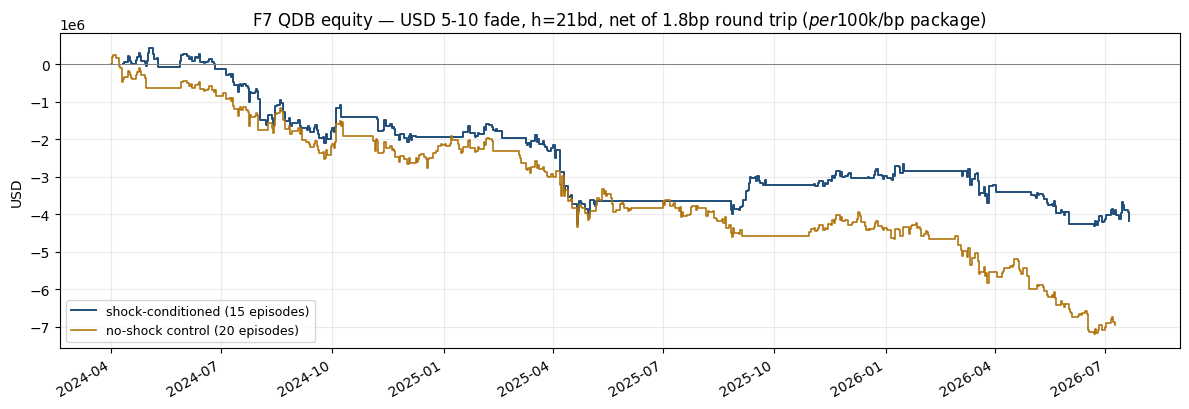

In [6]:
for nm, eq in (("shock (conditional)", eq_shock), ("no-shock (control)", eq_nosh)):
    daily = eq.diff().dropna()
    sd = daily.std(ddof=1)
    if len(daily) > 5 and sd > 0:
        print(f"{nm}: end {eq.iloc[-1]:+,.0f} USD, {len(daily)} marked days, "
              f"Sharpe {daily.mean() / sd * np.sqrt(252):+.2f}, "
              f"NW t {nw_tstat(daily.to_numpy()):+.2f}, "
              f"maxDD {(eq - eq.cummax()).min():,.0f} USD")

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.step(eq_shock.index, eq_shock.values, where="post", color="#1f4e79", lw=1.4,
        label=f"shock-conditioned ({len(tr_shock)} episodes)")
ax.step(eq_nosh.index, eq_nosh.values, where="post", color="#b1740f", lw=1.2,
        label=f"no-shock control ({len(tr_nosh)} episodes)")
ax.axhline(0, color="grey", lw=0.7)
ax.set_title(f"F7 QDB equity — USD {SIG} fade, h={H}bd, net of {RT_BP:.1f}bp round trip "
             f"($ per $100k/bp package)")
ax.set_ylabel("USD")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6. Tear sheet and closed positions

In [7]:
try:
    from BT.query_tearsheet import QueryBacktestTearSheet
    ts = QueryBacktestTearSheet.from_backtest(bt_shock)
    fig_ts = ts.plot_plotly()
    fig_ts.show()
except Exception as exc:                                   # noqa: BLE001 — reported, not hidden
    print(f"tearsheet unavailable: {type(exc).__name__}: {exc}")

In [8]:
cl = closed_frame(bt_shock)
print(f"closed-position rows: {len(cl)}")
if not cl.empty:
    show = [c for c in ["opened_at", "closed_at", "holding_period_steps",
                        "realized_pnl", "gross_realized_pnl", "fee_allocated"]
            if c in cl.columns]
    print(cl[show].head(8).to_string(index=False))
    pnl_col = next((c for c in cl.columns if "pnl" in c.lower()), None)
    if pnl_col:
        print(f"\nrealised P&L column {pnl_col!r}: total {cl[pnl_col].sum():+,.0f} USD, "
              f"median {cl[pnl_col].median():+,.0f}, "
              f"positive {int((cl[pnl_col] > 0).sum())}/{len(cl)}")

closed-position rows: 30
 opened_at  closed_at  holding_period_steps  realized_pnl  gross_realized_pnl  fee_allocated
2024-04-11 2024-05-10                    21 -6.455584e+05       -5.555584e+05        90000.0
2024-04-11 2024-05-10                    21  5.746030e+05        6.646030e+05        90000.0
2024-05-24 2024-06-26                    21 -1.912359e+06       -1.822359e+06        90000.0
2024-05-24 2024-06-26                    21  1.858705e+06        1.948705e+06        90000.0
2024-07-03 2024-08-02                    21  5.636450e+06        5.726450e+06        90000.0
2024-07-03 2024-08-02                    21 -7.008247e+06       -6.918247e+06        90000.0
2024-08-06 2024-09-05                    21  1.503497e+06        1.593497e+06        90000.0
2024-08-06 2024-09-05                    21 -1.699589e+06       -1.609589e+06        90000.0

realised P&L column 'realized_pnl': total -4,175,985 USD, median -4,747, positive 15/30


## 7. Trade timeline and signal overlay

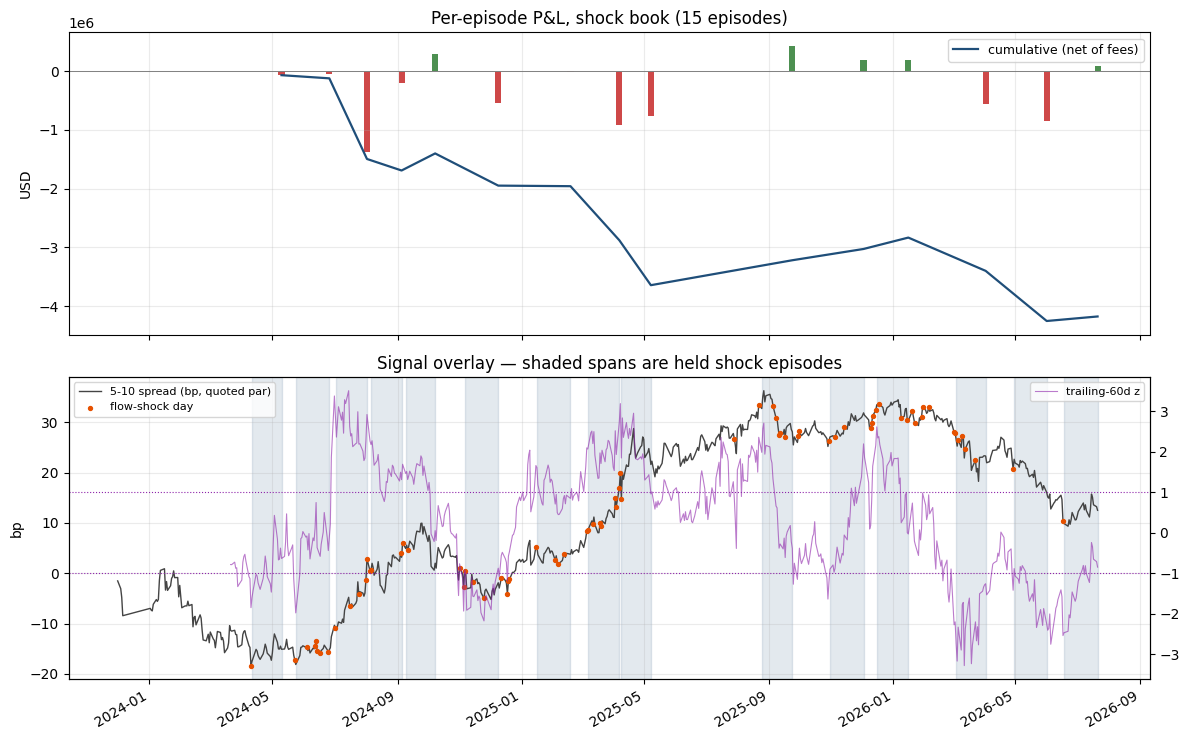

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)

ax = axes[0]
per_ep = per_episode_engine(bt_shock, tr_shock)
cum = per_ep.cumsum()
cols = ["#2e7d32" if v > 0 else "#c62828" for v in per_ep]
ax.bar(pd.to_datetime(tr_shock["exit_date"]), per_ep.values, width=6, color=cols, alpha=0.85)
ax.plot(pd.to_datetime(tr_shock["exit_date"]), cum.values, color="#1f4e79", lw=1.6,
        label="cumulative (net of fees)")
ax.axhline(0, color="grey", lw=0.7)
ax.set_title(f"Per-episode P&L, shock book ({len(tr_shock)} episodes)")
ax.set_ylabel("USD")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

ax = axes[1]
ax.plot(x.index, x.values, color="#444444", lw=1.0, label=f"{SIG} spread (bp, quoted par)")
ax2 = ax.twinx()
ax2.plot(z.index, z.values, color="#8e24aa", lw=0.8, alpha=0.6, label="trailing-60d z")
ax2.axhline(Z_ENTRY, color="#8e24aa", ls=":", lw=0.8)
ax2.axhline(-Z_ENTRY, color="#8e24aa", ls=":", lw=0.8)
for _, r in tr_shock.iterrows():
    ax.axvspan(pd.Timestamp(r["entry_date"]), pd.Timestamp(r["exit_date"]),
               color="#1f4e79", alpha=0.12)
sh_days = x.index[shock.reindex(x.index).fillna(False).to_numpy()]
ax.scatter(sh_days, x.reindex(sh_days).values, s=8, color="#e65100", zorder=5,
           label="flow-shock day")
ax.set_title("Signal overlay — shaded spans are held shock episodes")
ax.set_ylabel("bp")
ax.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 8. Verdict

House bar, at the ledger's trial count with `H-F7`'s **pre-stated** `sd(SR)`
source — the program's cross-family per-trade dispersion **0.275843**, which is
emphatically not the registered set (`L-0064`: a registration that does not
name its sd source is not registered).

In [10]:
net_bp_shock = tr_shock["gross_bp"] - RT_BP
net_bp_nosh = tr_nosh["gross_bp"] - RT_BP
sr_shock = float(net_bp_shock.mean() / net_bp_shock.std(ddof=1))

rows = []
for nm, s in (("shock", net_bp_shock), ("noshock", net_bp_nosh)):
    rows.append({
        "book": nm, "n": len(s),
        "gross_med_bp": float((s + RT_BP).median()),
        "net_mean_bp": float(s.mean()), "net_med_bp": float(s.median()),
        "per_trade_sharpe": float(s.mean() / s.std(ddof=1)),
        "hit": float((s > 0).mean()),
        "nw_t": float(nw_tstat(s.to_numpy())),
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

dsr_rows = []
for sd_src, sd_val in (("PRIMARY external (14 H13 arms)", 0.275843),
                       ("SENSITIVITY narrowed (ex-2 GBP arms)", 0.103300),
                       ("SENSITIVITY F7's own registered set", float(
                           gate[(gate.book == "shock") & (gate.h == H)]["sharpe_per_trade"]
                           .std(ddof=1)))):
    # per-TRADE returns, never annualised inside (design doc)
    d = deflated_sharpe(net_bp_shock.to_numpy(), n_trials=TRIALS_TOTAL,
                        sr_variance=sd_val ** 2, annualisation=1.0)
    dsr, sr0 = d["dsr_prob"], d["sr0"]
    dsr_rows.append({"sd_source": sd_src, "sd": sd_val, "dsr_prob": dsr,
                     "sr0_bar": sr0, "sr_per_trade": d["sr"]})
    print(f"DSR @ N={TRIALS_TOTAL}, sd(SR)={sd_val:.6f} [{sd_src}]: "
          f"{dsr:.4f}   (sr {d['sr']:+.4f} vs bar sr0 {sr0:.4f})")

# non-overlapping Sharpe wants the trade frame with an `entry` column
nos = tr_shock.rename(columns={"entry_date": "entry", "exit_date": "exit"}).copy()
nos["net_bp"] = net_bp_shock.to_numpy()
print(f"\nnon-overlapping Sharpe (shock): {nonoverlapping_sharpe(nos):.3f}")
print(f"increment (shock - noshock) median gross: "
      f"{(tr_shock['gross_bp'].median() - tr_nosh['gross_bp'].median()):+.3f} bp "
      f"against a {RT_BP:.1f} bp round trip")

verdict = {
    "arm": SIG, "h": H, "rt_bp": RT_BP, "trials_total": TRIALS_TOTAL,
    "engine_panel_corr": corr,
    "engine_end_usd": {"shock": float(eq_shock.iloc[-1]), "noshock": float(eq_nosh.iloc[-1])},
    "dsr": dsr_rows,
    "summary": summary.to_dict("records"),
    "sign_probe": {"pay": pay, "receive": rec, "spread_move_bp": d_rate},
    "status": "DEAD — engine confirms the panel; net negative at the registered line",
}
(DATA / "f7_qdb_verdict.json").write_text(json.dumps(verdict, indent=2, default=str),
                                          encoding="utf-8")
print("\nwrote f7_qdb_verdict.json")

   book  n  gross_med_bp  net_mean_bp  net_med_bp  per_trade_sharpe      hit      nw_t
  shock 15         1.318    -3.107733      -0.482         -0.549287 0.466667 -4.059631
noshock 20        -2.432    -3.803800      -4.232         -0.811508 0.100000 -7.593096
DSR @ N=55, sd(SR)=0.275843 [PRIMARY external (14 H13 arms)]: 0.0000   (sr -0.5493 vs bar sr0 0.6379)
DSR @ N=55, sd(SR)=0.103300 [SENSITIVITY narrowed (ex-2 GBP arms)]: 0.0002   (sr -0.5493 vs bar sr0 0.2389)
DSR @ N=55, sd(SR)=0.364848 [SENSITIVITY F7's own registered set]: 0.0000   (sr -0.5493 vs bar sr0 0.8437)

non-overlapping Sharpe (shock): -0.549
increment (shock - noshock) median gross: +3.750 bp against a 1.8 bp round trip

wrote f7_qdb_verdict.json
